# Synthetic Mechanical DINOv2 Anomaly Baseline

This notebook runs a GPU-backed DINOv2 patch-memory baseline on the generated
mechanical defects.

```text
normal mechanical image
  -> benign normal views
  -> DINOv2 patch embeddings
  -> normal patch memory bank

inspection image
  -> nearest-normal patch distance
  -> image anomaly score + defect heatmap
```

The current dataset has only two independent normal source images. Therefore,
this is an end-to-end proof of concept, not a trustworthy generalization
benchmark. Source 1 is used for memory/calibration and source 2 is held out for
testing.


## 1. Environment and Configuration


In [19]:
# Run only when dependencies are missing. PyTorch must already be the ROCm build.
# %pip install "numpy<2.3" "pandas<3" "scikit-learn<2" pillow matplotlib seaborn transformers


In [20]:
from pathlib import Path
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance
import seaborn as sns
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    jaccard_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from transformers import AutoImageProcessor, AutoModel

SEED = 42
MODEL_NAME = "facebook/dinov2-base"
IMAGE_SIZE = 224
BATCH_SIZE = 8
MAX_MEMORY_PATCHES = 30000
SIMILARITY_CHUNK_SIZE = 5000
TOP_PATCH_FRACTION = 0.05
NORMAL_MEMORY_VIEWS = 24
NORMAL_CALIBRATION_VIEWS = 12
NORMAL_TEST_VIEWS = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style="whitegrid")

# Absolute server path avoids dependence on Jupyter's current working directory.
DATASET_ROOT = Path(
    "/workspace/notebooks/data/synthetic_mechanical/generated"
)
MANIFEST_PATH = DATASET_ROOT / "manifest.csv"
ARTIFACT_ROOT = Path(
    "/workspace/notebooks/vision/artifacts/synthetic_mechanical/dinov2"
)
FIGURE_DIR = ARTIFACT_ROOT / "figures"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True

print("Dataset:", DATASET_ROOT)
print("Artifacts:", ARTIFACT_ROOT)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: DINOv2 is running on CPU.")


Dataset: /workspace/notebooks/data/synthetic_mechanical/generated
Artifacts: /workspace/notebooks/vision/artifacts/synthetic_mechanical/dinov2
Device: cuda
GPU: 


## 2. Load and Validate the Synthetic Manifest


In [21]:
if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {MANIFEST_PATH}. Run the synthetic generator first."
    )

manifest = pd.read_csv(MANIFEST_PATH).fillna("")
required_columns = {
    "sample_id", "label", "defect_type", "severity",
    "source_image", "image_path", "mask_path",
}
missing_columns = required_columns - set(manifest.columns)
if missing_columns:
    raise ValueError(f"Manifest is missing columns: {sorted(missing_columns)}")

for _, row in manifest.iterrows():
    image_path = DATASET_ROOT / row["image_path"]
    if not image_path.is_file():
        raise FileNotFoundError(image_path)
    if row["label"] == "anomaly":
        mask_path = DATASET_ROOT / row["mask_path"]
        if not mask_path.is_file():
            raise FileNotFoundError(mask_path)

normal_manifest = manifest[manifest["label"] == "normal"].copy()
anomaly_manifest = manifest[manifest["label"] == "anomaly"].copy()
sources = sorted(manifest["source_image"].unique())

if len(sources) < 2:
    raise ValueError("At least two independent source images are required.")

print("Normal records:", len(normal_manifest))
print("Anomaly records:", len(anomaly_manifest))
print("Independent sources:", sources)
display(
    anomaly_manifest.groupby(["source_image", "defect_type"])
    .size().to_frame("count")
)


Normal records: 2
Anomaly records: 200
Independent sources: ['Generated image 1.png', 'Generated image 2.png']


count
source_image          defect_type       
Generated image 1.png corrosion       20
                      crack           20
                      oil_leak        20
                      overheating     20
                      wear            20
Generated image 2.png corrosion       20
                      crack           20
                      oil_leak        20
                      overheating     20
                      wear            20

## 3. Source-Held-Out Experimental Split

All generated variants from the same source stay in the same split. This avoids
putting near-duplicate synthetic variants from one source in calibration and
test. With two sources, the first source is the development source and the
second is the held-out test source.


In [22]:
development_source = sources[0]
test_source = sources[1]


development_normal_rows = normal_manifest.reset_index(drop=True)

development_anomalies = anomaly_manifest[
    anomaly_manifest["source_image"] == sources[0]
].reset_index(drop=True)

test_anomalies = anomaly_manifest[
    anomaly_manifest["source_image"] == sources[1]
].reset_index(drop=True)

print("Normal sources used for memory:", len(development_normal_rows))
print("Calibration anomalies:", len(development_anomalies))
print("Test anomalies:", len(test_anomalies))


Normal sources used for memory: 2
Calibration anomalies: 100
Test anomalies: 100


## 4. Load DINOv2 on the AMD ROCm Device


In [23]:
processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
    crop_size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
    use_fast=False,
)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

patch_size = int(model.config.patch_size)
grid_height = IMAGE_SIZE // patch_size
grid_width = IMAGE_SIZE // patch_size
patch_count = grid_height * grid_width
embedding_dimension = int(model.config.hidden_size)

print("Model:", MODEL_NAME)
print("Patch grid:", (grid_height, grid_width))
print("Embedding dimension:", embedding_dimension)


Model: facebook/dinov2-base
Patch grid: (16, 16)
Embedding dimension: 768


## 5. Normal Views and Patch Utilities


In [24]:
def load_rgb(relative_path):
    return Image.open(DATASET_ROOT / relative_path).convert("RGB")


def benign_view(image, seed):
    rng = np.random.default_rng(seed)
    output = image.copy()
    if rng.random() < 0.5:
        output = output.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
    output = ImageEnhance.Brightness(output).enhance(
        float(rng.uniform(0.90, 1.10))
    )
    output = ImageEnhance.Contrast(output).enhance(
        float(rng.uniform(0.90, 1.10))
    )
    return output


def make_views(row, count, seed_offset):
    image = load_rgb(row["image_path"])
    return [
        benign_view(image, SEED + seed_offset + index)
        for index in range(count)
    ]


def extract_patch_embeddings(images, label="images"):
    batches = []
    total = len(images)
    started = time.perf_counter()
    for start in range(0, total, BATCH_SIZE):
        batch = images[start:start + BATCH_SIZE]
        inputs = processor(images=batch, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE)
        with torch.inference_mode():
            outputs = model(pixel_values=pixel_values)
            patches = F.normalize(
                outputs.last_hidden_state[:, 1:, :].float(),
                dim=-1,
            )
        batches.append(patches.cpu())
        completed = min(start + len(batch), total)
        print(
            f"  {label}: {completed}/{total}",
            end="\r" if completed < total else "\n",
            flush=True,
        )
    print(f"  Completed in {time.perf_counter() - started:.1f}s")
    return torch.cat(batches, dim=0)


def nearest_memory_distance(query_patches, memory_bank):
    query_patches = query_patches.to(DEVICE)
    best_similarity = torch.full(
        (len(query_patches),), -1.0, device=DEVICE
    )
    for start in range(0, len(memory_bank), SIMILARITY_CHUNK_SIZE):
        memory_chunk = memory_bank[
            start:start + SIMILARITY_CHUNK_SIZE
        ].to(DEVICE)
        similarity = query_patches @ memory_chunk.T
        best_similarity = torch.maximum(
            best_similarity, similarity.max(dim=1).values
        )
    return (1.0 - best_similarity).clamp(min=0).cpu()


def score_from_patches(patch_scores):
    top_count = max(
        1, int(math.ceil(len(patch_scores) * TOP_PATCH_FRACTION))
    )
    return float(torch.topk(patch_scores, top_count).values.mean())


## 6. Build the Normal Patch Memory Bank


In [25]:
memory_views = []

for row_index, row in development_normal_rows.iterrows():
    memory_views.extend(
        make_views(
            row,
            NORMAL_MEMORY_VIEWS,
            seed_offset=1000 + row_index * 100,
        )
    )
memory_embeddings = extract_patch_embeddings(
    memory_views, label="normal memory views"
)
all_memory_patches = memory_embeddings.reshape(-1, embedding_dimension)

generator = torch.Generator().manual_seed(SEED)
if len(all_memory_patches) > MAX_MEMORY_PATCHES:
    selected = torch.randperm(
        len(all_memory_patches), generator=generator
    )[:MAX_MEMORY_PATCHES]
    memory_bank = all_memory_patches[selected].contiguous()
else:
    memory_bank = all_memory_patches.contiguous()

print("Memory-bank shape:", tuple(memory_bank.shape))
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


  normal memory views: 48/48
  Completed in 0.6s
Memory-bank shape: (12288, 768)


## 7. Score Calibration and Test Records


In [26]:
def score_images(images, identifiers, rows=None, label="images"):
    embeddings = extract_patch_embeddings(images, label=label)
    records = []
    maps = {}
    for index, identifier in enumerate(identifiers):
        patch_scores = nearest_memory_distance(
            embeddings[index], memory_bank
        )
        patch_map = patch_scores.reshape(
            grid_height, grid_width
        ).numpy()
        record = {
            "identifier": identifier,
            "image_score": score_from_patches(patch_scores),
        }
        if rows is not None:
            row = rows.iloc[index]
            record.update({
                "sample_id": row["sample_id"],
                "label": row["label"],
                "defect_type": row["defect_type"],
                "severity": row["severity"],
                "source_image": row["source_image"],
                "image_path": row["image_path"],
                "mask_path": row["mask_path"],
            })
        records.append(record)
        maps[identifier] = patch_map
    return pd.DataFrame(records), maps


calibration_normal_views = make_views(
    development_normal, NORMAL_CALIBRATION_VIEWS, seed_offset=3000
)
calibration_normal_scores, calibration_normal_maps = score_images(
    calibration_normal_views,
    [f"calibration_normal_{i:03d}" for i in range(NORMAL_CALIBRATION_VIEWS)],
    label="calibration normal views",
)
calibration_normal_scores["label"] = "normal"

calibration_anomaly_images = [
    load_rgb(path) for path in development_anomalies["image_path"]
]
calibration_anomaly_scores, calibration_anomaly_maps = score_images(
    calibration_anomaly_images,
    development_anomalies["sample_id"].tolist(),
    rows=development_anomalies,
    label="calibration anomalies",
)

test_normal_views = make_views(
    test_normal, NORMAL_TEST_VIEWS, seed_offset=5000
)
test_normal_scores, test_normal_maps = score_images(
    test_normal_views,
    [f"test_normal_{i:03d}" for i in range(NORMAL_TEST_VIEWS)],
    label="held-out normal views",
)
test_normal_scores["label"] = "normal"

test_anomaly_images = [
    load_rgb(path) for path in test_anomalies["image_path"]
]
test_anomaly_scores, test_anomaly_maps = score_images(
    test_anomaly_images,
    test_anomalies["sample_id"].tolist(),
    rows=test_anomalies,
    label="held-out anomalies",
)


  calibration normal views: 12/12
  Completed in 0.1s
  calibration anomalies: 100/100
  Completed in 1.2s
  held-out normal views: 20/20
  Completed in 0.3s
  held-out anomalies: 100/100
  Completed in 1.2s


## 8. Calibrate Image and Pixel Thresholds


In [27]:
def best_f1_threshold(labels, scores):
    best = None
    for threshold in np.unique(scores):
        predictions = (scores >= threshold).astype(int)
        candidate = {
            "threshold": float(threshold),
            "precision": float(
                precision_score(labels, predictions, zero_division=0)
            ),
            "recall": float(
                recall_score(labels, predictions, zero_division=0)
            ),
            "f1": float(f1_score(labels, predictions, zero_division=0)),
        }
        if best is None or candidate["f1"] > best["f1"]:
            best = candidate
    return best


calibration_scores = pd.concat(
    [calibration_normal_scores, calibration_anomaly_scores],
    ignore_index=True,
)
calibration_labels = (
    calibration_scores["label"] == "anomaly"
).astype(int).to_numpy()
calibration_values = calibration_scores["image_score"].to_numpy()
image_threshold_metrics = best_f1_threshold(
    calibration_labels, calibration_values
)
IMAGE_THRESHOLD = image_threshold_metrics["threshold"]


def load_patch_mask(relative_path):
    mask = Image.open(DATASET_ROOT / relative_path).convert("L")
    mask = mask.resize(
        (grid_width, grid_height), Image.Resampling.NEAREST
    )
    return (np.asarray(mask) > 0).astype(np.uint8)


pixel_scores = []
pixel_labels = []
for _, row in calibration_anomaly_scores.iterrows():
    pixel_scores.append(
        calibration_anomaly_maps[row["identifier"]].reshape(-1)
    )
    pixel_labels.append(load_patch_mask(row["mask_path"]).reshape(-1))

pixel_threshold_metrics = best_f1_threshold(
    np.concatenate(pixel_labels),
    np.concatenate(pixel_scores),
)
PIXEL_THRESHOLD = pixel_threshold_metrics["threshold"]

display(pd.DataFrame([image_threshold_metrics]))
display(pd.DataFrame([pixel_threshold_metrics]))


,threshold,precision,recall,f1
0,0.00298,0.900901,1.0,0.947867


,threshold,precision,recall,f1
0,0.050017,0.434298,0.611285,0.507812


## 9. Held-Out Test Evaluation


,experimental,roc_auc,pr_auc,precision,recall,f1,false_alarms,missed_anomalies
0,True,0.91,0.982987,0.858407,0.97,0.910798,16,3


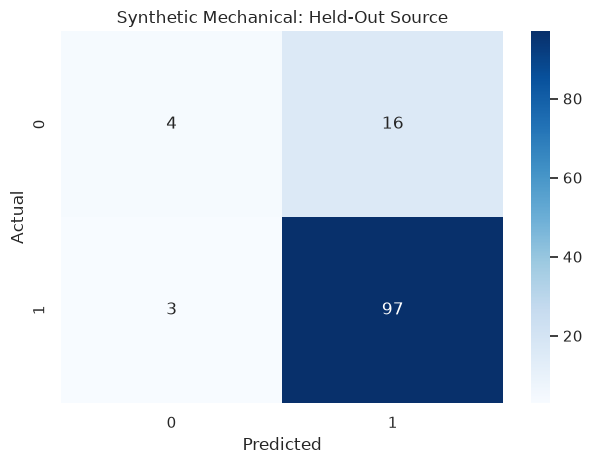

,experimental,pixel_roc_auc,pixel_average_precision,pixel_f1,mean_anomaly_iou
0,True,0.970923,0.417709,0.488701,0.286301


In [28]:
test_scores = pd.concat(
    [test_normal_scores, test_anomaly_scores], ignore_index=True
)
test_labels = (
    test_scores["label"] == "anomaly"
).astype(int).to_numpy()
test_values = test_scores["image_score"].to_numpy()
test_predictions = (test_values >= IMAGE_THRESHOLD).astype(int)

image_metrics = {
    "experimental": True,
    "roc_auc": float(roc_auc_score(test_labels, test_values)),
    "pr_auc": float(average_precision_score(test_labels, test_values)),
    "precision": float(
        precision_score(test_labels, test_predictions, zero_division=0)
    ),
    "recall": float(
        recall_score(test_labels, test_predictions, zero_division=0)
    ),
    "f1": float(f1_score(test_labels, test_predictions, zero_division=0)),
    "false_alarms": int(
        ((test_predictions == 1) & (test_labels == 0)).sum()
    ),
    "missed_anomalies": int(
        ((test_predictions == 0) & (test_labels == 1)).sum()
    ),
}
display(pd.DataFrame([image_metrics]))

matrix = confusion_matrix(test_labels, test_predictions)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Synthetic Mechanical: Held-Out Source")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "image_confusion_matrix.png", dpi=150)
plt.show()

test_maps = {**test_normal_maps, **test_anomaly_maps}
all_pixel_scores = []
all_pixel_labels = []
image_ious = []

for _, row in test_anomaly_scores.iterrows():
    score_map = test_maps[row["identifier"]]
    true_mask = load_patch_mask(row["mask_path"])
    predicted_mask = (score_map >= PIXEL_THRESHOLD).astype(np.uint8)
    all_pixel_scores.append(score_map.reshape(-1))
    all_pixel_labels.append(true_mask.reshape(-1))
    image_ious.append(
        jaccard_score(
            true_mask.reshape(-1),
            predicted_mask.reshape(-1),
            zero_division=0,
        )
    )

for identifier in test_normal_scores["identifier"]:
    score_map = test_maps[identifier]
    all_pixel_scores.append(score_map.reshape(-1))
    all_pixel_labels.append(
        np.zeros(score_map.size, dtype=np.uint8)
    )

all_pixel_scores = np.concatenate(all_pixel_scores)
all_pixel_labels = np.concatenate(all_pixel_labels)
pixel_predictions = (
    all_pixel_scores >= PIXEL_THRESHOLD
).astype(int)

pixel_metrics = {
    "experimental": True,
    "pixel_roc_auc": float(
        roc_auc_score(all_pixel_labels, all_pixel_scores)
    ),
    "pixel_average_precision": float(
        average_precision_score(all_pixel_labels, all_pixel_scores)
    ),
    "pixel_f1": float(
        f1_score(
            all_pixel_labels, pixel_predictions, zero_division=0
        )
    ),
    "mean_anomaly_iou": float(np.mean(image_ious)),
}
display(pd.DataFrame([pixel_metrics]))


## 10. Defect Heatmaps


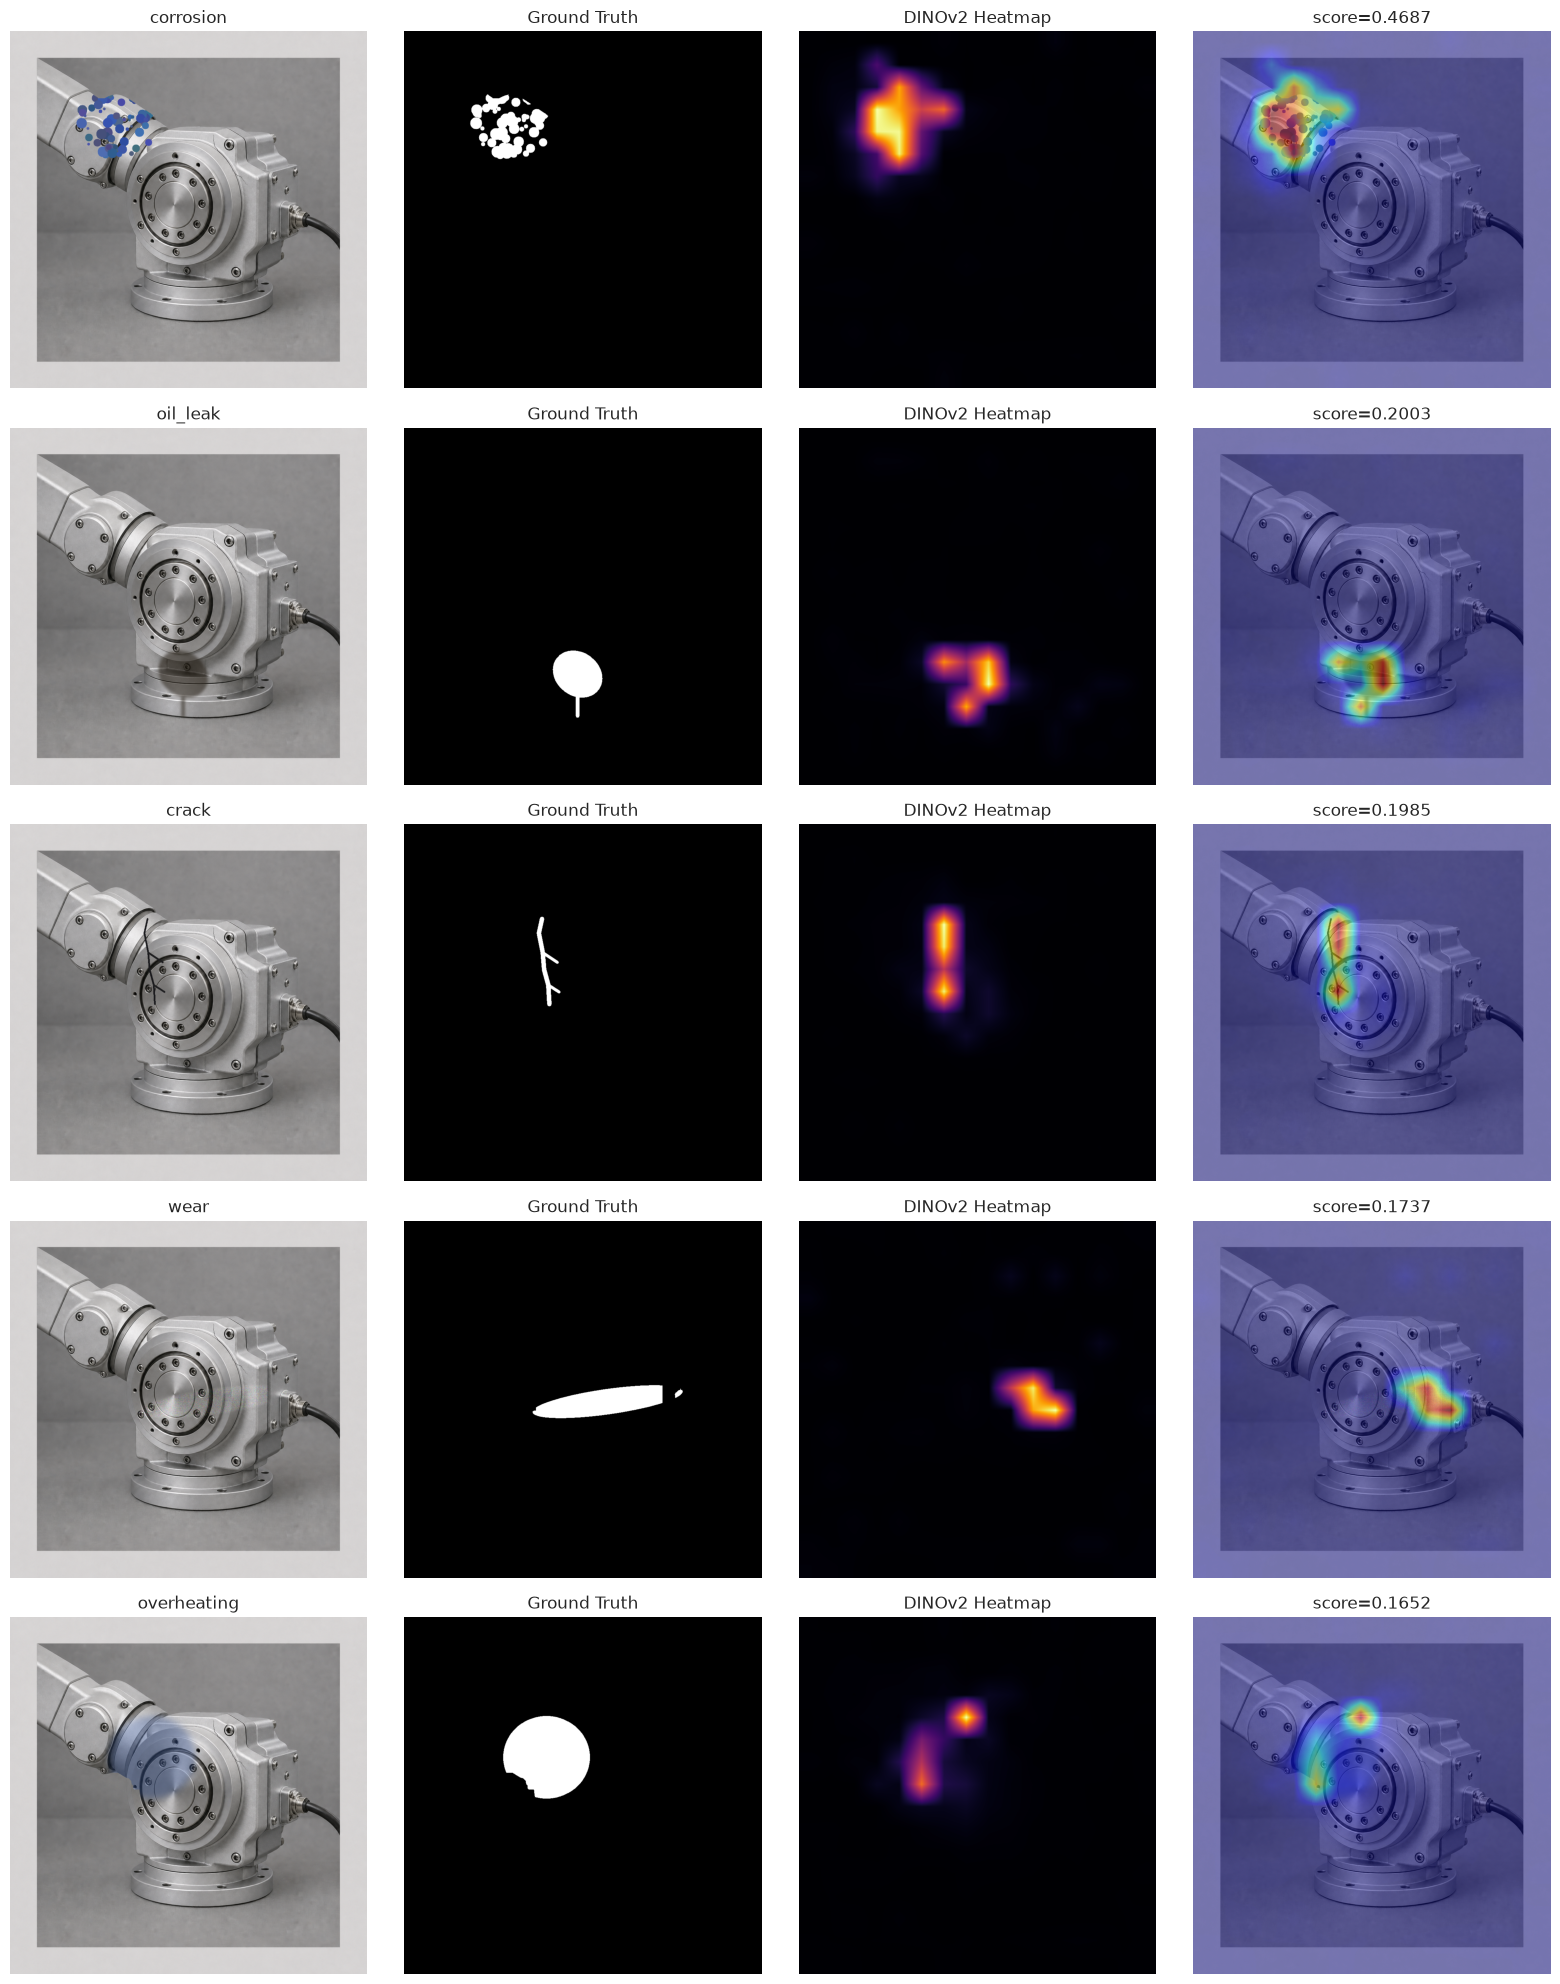

In [29]:
def upsample_heatmap(patch_map, image_size):
    tensor = torch.from_numpy(patch_map)[None, None].float()
    return F.interpolate(
        tensor,
        size=(image_size[1], image_size[0]),
        mode="bilinear",
        align_corners=False,
    )[0, 0].numpy()


examples = (
    test_anomaly_scores.sort_values("image_score", ascending=False)
    .groupby("defect_type", group_keys=False)
    .head(1)
)
fig, axes = plt.subplots(
    len(examples), 4, figsize=(16, 4 * len(examples))
)

for row_index, (_, row) in enumerate(examples.iterrows()):
    image = load_rgb(row["image_path"])
    mask = Image.open(DATASET_ROOT / row["mask_path"]).convert("L")
    heatmap = upsample_heatmap(
        test_maps[row["identifier"]], image.size
    )
    axes[row_index, 0].imshow(image)
    axes[row_index, 0].set_title(row["defect_type"])
    axes[row_index, 1].imshow(mask, cmap="gray")
    axes[row_index, 1].set_title("Ground Truth")
    axes[row_index, 2].imshow(heatmap, cmap="inferno")
    axes[row_index, 2].set_title("DINOv2 Heatmap")
    axes[row_index, 3].imshow(image)
    axes[row_index, 3].imshow(heatmap, cmap="jet", alpha=0.45)
    axes[row_index, 3].set_title(
        f"score={row['image_score']:.4f}"
    )
    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "defect_heatmaps.png", dpi=150)
plt.show()


## 11. Save Artifacts and Vision Contract


In [31]:
test_results = test_scores.copy()
test_results["true_label"] = test_labels
test_results["predicted_label"] = test_predictions
test_results.to_csv(
    ARTIFACT_ROOT / "test_results.csv",
    index=False,
)

torch.save(
    {
        "memory_bank": memory_bank,
        "model_name": MODEL_NAME,
        "image_size": IMAGE_SIZE,
        "patch_size": patch_size,
        "grid_height": grid_height,
        "grid_width": grid_width,
        "normal_memory_sources": sources,
        "evaluation_mode": "functional_demo_no_independent_normal_test",
    },
    ARTIFACT_ROOT / "normal_patch_memory.pt",
)

top_anomaly = test_anomaly_scores.sort_values(
    "image_score",
    ascending=False,
).iloc[0]

vision_contract = {
    "scenario_id": "SYNTH-MECH-001",
    "asset_id": Path(top_anomaly["source_image"]).stem,
    "anomaly_score": float(top_anomaly["image_score"]),
    "is_anomaly": bool(
        top_anomaly["image_score"] >= IMAGE_THRESHOLD
    ),
    "predicted_fault": "visual_anomaly",
    "severity": "unknown",
    "location": "dinov2_patch_heatmap",
    "image_path": top_anomaly["image_path"],
    "evidence": {
        "model": MODEL_NAME,
        "image_threshold": float(IMAGE_THRESHOLD),
        "pixel_threshold": float(PIXEL_THRESHOLD),
        "normal_memory_sources": list(sources),
        "evaluation_mode": (
            "functional_demo_no_independent_normal_test"
        ),
    },
    "limitations": [
        "Synthetic defects are programmatic overlays.",
        "Only two independent normal source images were available.",
        "Both normal sources were used in the memory bank.",
        "There is no independent normal test set.",
        "Metrics are experimental and do not establish deployment accuracy.",
        "DINOv2 detects and localizes anomalies but does not classify defect type.",
    ],
}

metadata = {
    "dataset": "Synthetic Mechanical Defects",
    "experimental": True,
    "evaluation_mode": (
        "functional_demo_no_independent_normal_test"
    ),
    "model_name": MODEL_NAME,
    "normal_memory_sources": list(sources),
    "memory_bank_patches": int(len(memory_bank)),
    "image_threshold": float(IMAGE_THRESHOLD),
    "pixel_threshold": float(PIXEL_THRESHOLD),
    "image_metrics": image_metrics,
    "pixel_metrics": pixel_metrics,
    "limitations": vision_contract["limitations"],
}

(ARTIFACT_ROOT / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

(ARTIFACT_ROOT / "vision_contract_example.json").write_text(
    json.dumps(vision_contract, indent=2),
    encoding="utf-8",
)

print("Artifacts saved to:", ARTIFACT_ROOT)
print(json.dumps(vision_contract, indent=2))

Artifacts saved to: /workspace/notebooks/vision/artifacts/synthetic_mechanical/dinov2
{
  "scenario_id": "SYNTH-MECH-001",
  "asset_id": "Generated image 2",
  "anomaly_score": 0.4687260389328003,
  "is_anomaly": true,
  "predicted_fault": "visual_anomaly",
  "severity": "unknown",
  "location": "dinov2_patch_heatmap",
  "image_path": "anomaly/corrosion/Generated image 2_corrosion_008.png",
  "evidence": {
    "model": "facebook/dinov2-base",
    "image_threshold": 0.0029801358468830585,
    "pixel_threshold": 0.05001652240753174,
    "normal_memory_sources": [
      "Generated image 1.png",
      "Generated image 2.png"
    ],
    "evaluation_mode": "functional_demo_no_independent_normal_test"
  },
  "limitations": [
    "Synthetic defects are programmatic overlays.",
    "Only two independent normal source images were available.",
    "Both normal sources were used in the memory bank.",
    "There is no independent normal test set.",
    "Metrics are experimental and do not establish

## Completion Criteria

- ROCm GPU is detected.
- A normal DINOv2 patch memory bank is built.
- Thresholds are selected only from the development source.
- The second source remains held out until test evaluation.
- Image and pixel metrics are reported.
- Heatmaps are generated for all five defect types.
- Artifacts and the vision contract are saved.

Do not fine-tune DINOv2 yet. First inspect baseline metrics and heatmap quality.
